In [53]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
# Загрузка данных
 
data = pd.read_csv('twitter-posts.csv')
print(data.shape)

(1000, 25)


In [55]:
print(data.dtypes)

id                       int64
user_posted                str
name                       str
description                str
date_posted                str
photos                     str
videos                     str
url                        str
quoted_post                str
tagged_users               str
replies                  int64
reposts                  int64
likes                    int64
views                  float64
external_url               str
hashtags                   str
followers                int64
biography                  str
posts_count              int64
profile_image_link         str
following                int64
is_verified               bool
quotes                   int64
bookmarks                int64
parent_post_details        str
dtype: object


In [56]:
print(data.isnull().sum())

id                       0
user_posted              0
name                     0
description              0
date_posted              0
photos                 453
videos                 814
url                      0
quoted_post              0
tagged_users           561
replies                  0
reposts                  0
likes                    0
views                    5
external_url           780
hashtags               767
followers                0
biography                3
posts_count              0
profile_image_link       0
following                0
is_verified              0
quotes                   0
bookmarks                0
parent_post_details      0
dtype: int64


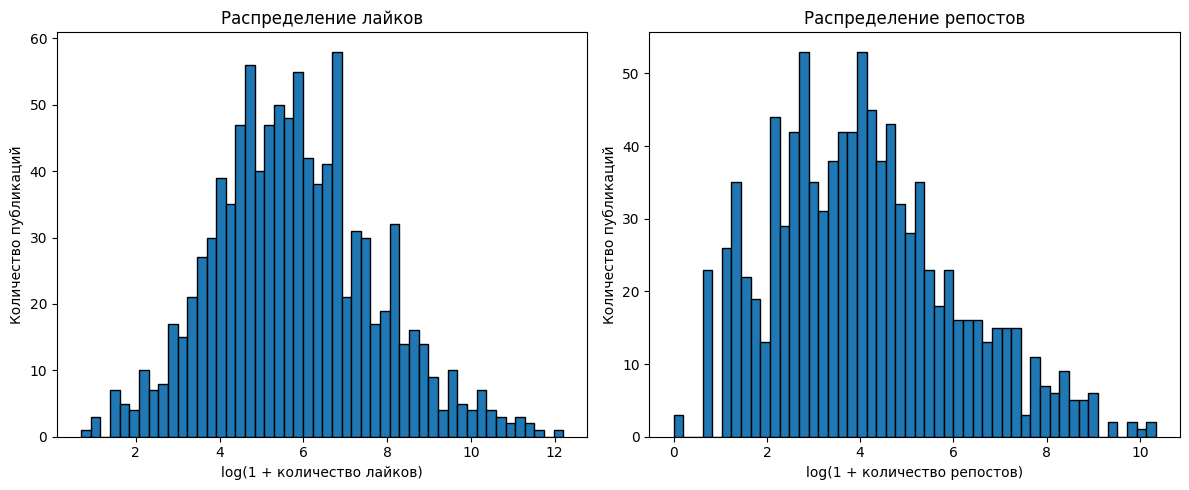

,likes,reposts
count,1000.000000,1000.000000
mean,2520.424000,510.071000
std,10596.936461,2053.985342
min,1.000000,0.000000
25%,89.000000,13.000000
50%,296.500000,50.000000
75%,996.750000,186.500000
max,200617.000000,30947.000000


In [57]:
# Анализ распределения целевых переменных 
 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
 
ax[0].hist(np.log1p(data['likes']), bins=50, edgecolor='black')
ax[0].set_xlabel('log(1 + количество лайков)')
ax[0].set_ylabel('Количество публикаций')
ax[0].set_title('Распределение лайков')

ax[1].hist(np.log1p(data['reposts']), bins=50, edgecolor='black')
ax[1].set_xlabel('log(1 + количество репостов)')
ax[1].set_ylabel('Количество публикаций')
ax[1].set_title('Распределение репостов') 
plt.tight_layout()
plt.show()

data[['likes', 'reposts']].describe()

In [58]:
# Предобработка данных 
 
# Удаление дубликатов
data = data.drop_duplicates(subset='description')
 
# Обработка пропусков в необязательных полях
fill_cols = ['photos', 'videos', 'hashtags', 'external_url', 'tagged_users']
for col in fill_cols:
    data[col] = data[col].fillna('')
data['biography'] = data['biography'].fillna('')
 
# Бинарные признаки наличия контента
data['has_photo'] = (data['photos'].astype(str).str.len() > 0).astype(int)
data['has_video'] = (data['videos'].astype(str).str.len() > 0).astype(int)
data['has_hashtags'] = (data['hashtags'].astype(str).str.len() > 0).astype(int)
data['has_url'] = (data['external_url'].astype(str).str.len() > 0).astype(int)
 
# Обработка даты публикации
data['date_posted'] = (
    data['date_posted']
    .astype(str)
    .str.replace('"', '')
)
data['date_posted'] = pd.to_datetime(
    data['date_posted'],
    errors='coerce',
    utc=True
)
data = data.dropna(subset=['date_posted']).reset_index(drop=True)
 
# Временные признаки
data['hour']        = data['date_posted'].dt.hour
data['day_of_week'] = data['date_posted'].dt.dayofweek
data['is_weekend']  = (data['day_of_week'] >= 5).astype(int)
 
def time_of_day(hour):
    if   6 <= hour < 12: return 0  # утро
    elif 12 <= hour < 18: return 1  # день
    elif 18 <= hour < 23: return 2  # вечер
    else: return 3  # ночь
 
data['time_of_day'] = data['hour'].apply(time_of_day)
 
# Признак верификации
data['is_verified'] = data['is_verified'].fillna(0).astype(int)
 
# Очистка текста
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zа-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
 
data['clean_text'] = data['description'].apply(clean_text)
 
# Дополнительные текстовые признаки
data['text_length'] = data['description'].astype(str).apply(len)
data['word_count'] = data['description'].astype(str).apply(lambda x: len(x.split()))

In [59]:
# Формирование признаков 
 
num_cols = [
    'followers', 'following', 'posts_count',
    'hour', 'day_of_week', 'is_weekend', 'time_of_day',
    'text_length', 'word_count',
    'has_photo', 'has_video', 'has_hashtags', 'has_url', 'is_verified'
]
 
data[num_cols] = data[num_cols].fillna(0)

In [60]:
# Целевые переменные
 
y_likes = data['likes'].values
y_reposts = data['reposts'].values

In [61]:
# Разбиение на обучающую и тестовую выборки
 
indices = np.arange(len(data))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_data = data.iloc[train_idx].reset_index(drop=True)
test_data = data.iloc[test_idx].reset_index(drop=True)

In [62]:
# Нормализация числовых признаков 
 
scale_cols = ['followers', 'following', 'posts_count', 'text_length', 'word_count']
scaler = MinMaxScaler()
train_data[scale_cols] = scaler.fit_transform(train_data[scale_cols])
test_data[scale_cols] = scaler.transform(test_data[scale_cols])

In [63]:
# TF-IDF признаки

tfidf = TfidfVectorizer(max_features=300, min_df=2)
 
tfidf_train = pd.DataFrame(
    tfidf.fit_transform(train_data['clean_text']).toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_test = pd.DataFrame(
    tfidf.transform(test_data['clean_text']).toarray(),
    columns=tfidf.get_feature_names_out()
)
 
# Итоговые матрицы признаков
X_train = pd.concat([train_data[num_cols].reset_index(drop=True), tfidf_train], axis=1)
X_test = pd.concat([test_data[num_cols].reset_index(drop=True), tfidf_test], axis=1)
 
print("Пропуски в X_train:", X_train.isnull().sum().sum())
print("Размер матрицы признаков:", X_train.shape)
 
# Целевые переменные для train/test
y_likes_train = y_likes[train_idx]
y_likes_test = y_likes[test_idx]
y_reposts_train = y_reposts[train_idx]
y_reposts_test = y_reposts[test_idx]

Пропуски в X_train: 0
Размер матрицы признаков: (800, 314)


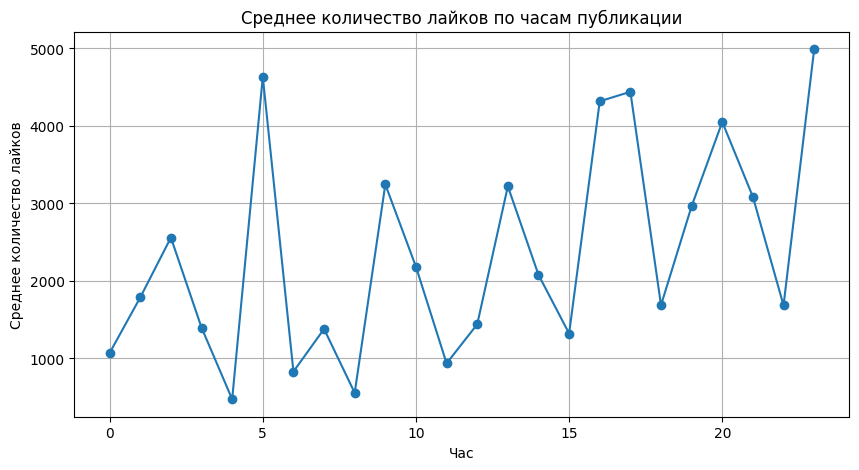

In [64]:
# График среднего количества лайков по часам 
 
hour_stats = data.groupby('hour')['likes'].mean()
plt.figure(figsize=(10, 5))
plt.plot(hour_stats.index, hour_stats.values, marker='o')
plt.title('Среднее количество лайков по часам публикации')
plt.xlabel('Час')
plt.ylabel('Среднее количество лайков')
plt.grid()
plt.show()

In [65]:
# Обучение модели линейной регрессии ────────────────────────────────────
 
model_likes = LinearRegression()
model_likes.fit(X_train, y_likes_train)
model_reposts = LinearRegression()
model_reposts.fit(X_train, y_reposts_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
# Предсказания
 
likes_pred = model_likes.predict(X_test)
reposts_pred = model_reposts.predict(X_test)

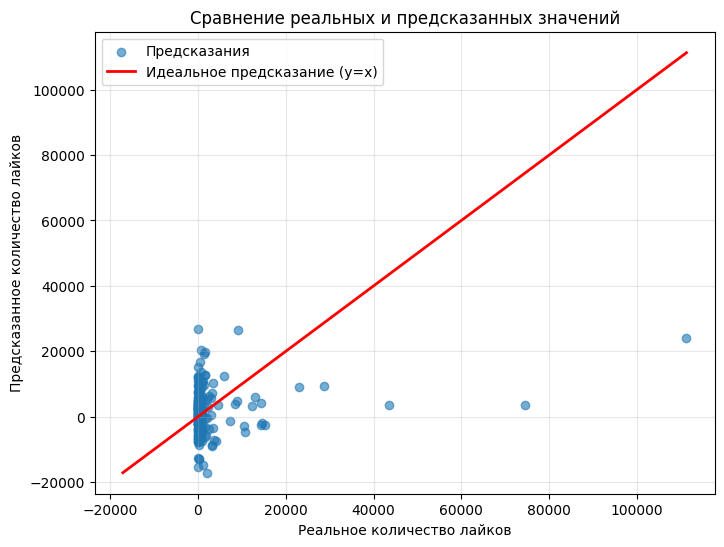

In [67]:
# Результа для лайков
plt.figure(figsize=(8, 6))
plt.scatter(y_likes_test, likes_pred, alpha=0.6, label='Предсказания')
min_val = min(min(y_likes_test), min(likes_pred))
max_val = max(max(y_likes_test), max(likes_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Идеальное предсказание (y=x)')
plt.xlabel('Реальное количество лайков')
plt.ylabel('Предсказанное количество лайков')
plt.title('Сравнение реальных и предсказанных значений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

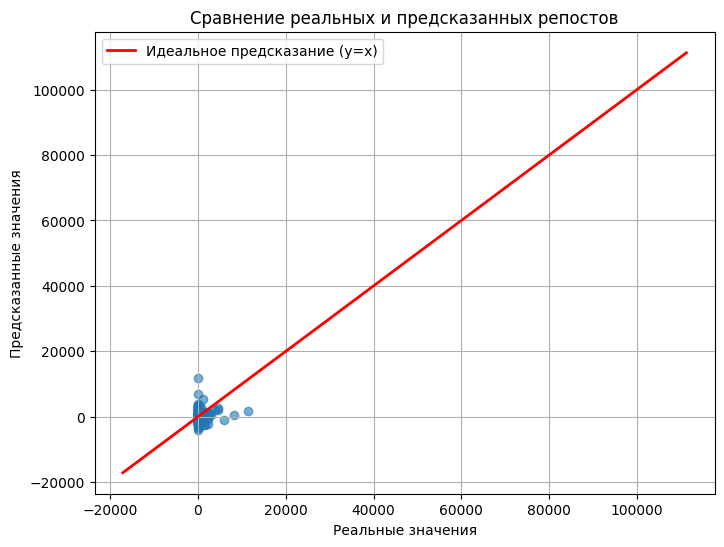

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(y_reposts_test, reposts_pred, alpha=0.6)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение реальных и предсказанных репостов')
min_val = min(min(y_likes_test), min(likes_pred))
max_val = max(max(y_likes_test), max(likes_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Идеальное предсказание (y=x)')
plt.legend()
plt.grid()
plt.show()

In [69]:
# Оценка качества модели
 
print('Метрики для лайков')
print('MAE: ', mean_absolute_error(y_likes_test, likes_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_likes_test, likes_pred)))
print('R2: ', r2_score(y_likes_test, likes_pred))
 
print('\nМетрики для репостов')
print('MAE: ', mean_absolute_error(y_reposts_test, reposts_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_reposts_test, reposts_pred)))
print('R2: ', r2_score(y_reposts_test, reposts_pred))

Метрики для лайков
MAE:  6716.988563840099
RMSE: 11303.736387885647
R2:  -0.1790933946909623

Метрики для репостов
MAE:  1420.5738909659945
RMSE: 2121.642670968214
R2:  -1.848912316221191
